<a href="https://colab.research.google.com/github/sk27110/Optimization_methods/blob/Lab1/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0__Lab01_OptMet_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Градиентный спуск

В данном задании необходимо реализовать метод градиентного спуска (функция gradient_descent) и
процедуру линейного поиска (метод line_search в класce LineSearchTool в модуле optimization).



**Алгоритм 1: Общая схема метода спуска**

**Вход:** Начальная точка $x_0$; максимальное число итераций $K$.

1. **for** $k \leftarrow 0$ **to** $K$ **do**
2. &emsp; **(Вызов оракула)** Вычислить $f(x_k)$, $\nabla f(x_k)$ и пр.
3. &emsp; **(Критерий остановки)** Если выполнен критерий остановки, то выход.
4. &emsp; **(Вычисление направления)** Вычислить направление спуска $d_k$.
5. &emsp; **(Линейный поиск)** Найти подходящую длину шага $\alpha_k$.
6. &emsp; **(Обновление)** $x_{k+1} \leftarrow x_k + \alpha_k d_k$.
7. **end for**

**Выход:** Последняя вычисленная точка $x_k$

In [ ]:
import numpy as np
from numpy.linalg import LinAlgError
import scipy
from datetime import datetime
from collections import defaultdict
from scipy.special import expit
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

**Критерий остановки**

Наиболее популярным критерием остановки является критерий, основанный на норме градиента: $\| \nabla f(x_k) \|_2^2 < \tilde{\varepsilon}$.  
Квадрат здесь ставят за тем, что для «хороших» функций невязка по функции $f(x_k) - f^*$ имеет тот же порядок, что $u = \| \nabla f(x_k) \|_2^2$, а не $\| \nabla f(x_k) \|_2^1$; например, если $\| \nabla f(x_k) \|_2 \sim 10^{-5}$, то $f(x_k) - f^* \sim 10^{-10}$.  
Наконец, для того, чтобы критерий не зависел от того, измеряется ли функция $f$ «в метрах» или «в километрах» (т. е. не изменялся при переходе от функции $f$ к функции $tf$, где $t > 0$), то имеет смысл использовать следующий относительный вариант критерия:  

$$\| \nabla f(x_k) \|_2^2 \leq \epsilon \| \nabla f(x_0) \|_2^2$$

где $\epsilon \in (0, 1)$ — заданная относительная точность. Таким образом, данный критерий остановки гарантирует, что метод уменьшит начальную невязку $\| \nabla f(x_0) \|_2$ в $\epsilon^{-1}$ раз. В этом задании Вам нужно будет во всех методах использовать этот критерий остановки.


**Линейный поиск**

Рассматривается функция  
$$\phi_k(\alpha) := f(x_k + \alpha d_k)$$


Заметим, что  
$$\phi_k'(\alpha) = \langle \nabla f(x_k + \alpha d_k), d_k \rangle $$

Поскольку $d_k$ является направлением спуска, то $\phi'(0) = \langle \nabla f(x_k), d_k \rangle < 0$.

Условием Армихо для $\alpha$ называется выполнение следующего неравенства:  
$$\phi_k(\alpha) \leq \phi_k(0) + c_1 \alpha \phi_k'(0)$$

где $c_1 \in (0, 0.5)$ - некоторая константа.

Для поиска точки $\alpha$, удовлетворяющей условию Армихо, обычно используют следующую процедуру - метод дробления шага (бэктрэкинг):


**Алгоритм 2: Метод дробления шага (бэктрэкинг)**

**Вход:** Функция $\phi_k : \mathbb{R}_+ \rightarrow \mathbb{R}$; начальное значение шага $\alpha_k^{(0)}$.

1. $\alpha \leftarrow \alpha_k^{(0)}$
2. **while** $\phi_k(\alpha) > \phi_k(0) + c_1 \alpha \phi_k'(0)$ **do**
3. &emsp; $\alpha \leftarrow \alpha/2$
4. **end while**

**Выход:** $\alpha$

«Адаптивный» метод подбора шага запоминает величину $\alpha_k$, найденную на текущей итерации и на следующей итерации начинает процедуру дробления с $\alpha_{k+1}^{(0)} := 2\alpha_k$. Исключение здесь составляют ньютоновские и квазиньютоновские методы - в этих методах процедуру дробления шага всегда нужно начинать с $\alpha_k^{(0)} := 1$.

Сильные условия Вульфа:
$$\phi_k(\alpha) \leq \phi(0) + c_1 \alpha \phi_k'(0)$$
$$| \phi_k'(\alpha)| \leq c_2 |\phi_k'(0)|
$$

Здесь $c_1 \in (0, 0.5), c_2 \in (c_1, 1)$.


*Рекомендация:* Для поиска точки, удовлетворяющей сильным условиям Вульфа,
воспользуйтесь библиотечной функцией scalar_search_wolfe2 из модуля scipy.optimize.linesearch. В ней начальная длина шага $\alpha_k^{(0)}$ автоматически выбирается равной 1.
Однако следует иметь в виду, что у этой библиотечной функции имеется один недостаток: она иногда не сходится и возвращает значение None.
Если библиотечный метод вернул None, то запустите процедуру дробления шага (бэктрекинг) для поиска точки, удовлетворяющей условию Армихо.
Для методов Brent и golden можно использовать scipy.optimize.minimize_scalar


In [ ]:
from scipy.optimize._linesearch import scalar_search_wolfe2
from scipy.optimize import minimize_scalar

class LineSearchTool(object):
    """
    Line search tool for adaptively tuning the step size of the algorithm.

    method : String containing 'Wolfe', 'Armijo', 'Constant', 'Brent' anvvvd 'Golden',
        Method of tuning step-size.
        Must be be one of the following strings:
            - 'Wolfe' -- enforce strong Wolfe conditions;
            - 'Armijo" -- adaptive Armijo rule;
            - 'Constant' -- constant step size;
            - 'Brent' -- Brent's method for exact line search;
            - 'Golden' -- golden section search for exact line search..
    kwargs :
        Additional parameters of line_search method:

        If method == 'Wolfe':
            c1, c2 : Constants for strong Wolfe conditions
            alpha_0 : Starting point for the backtracking procedure
                to be used in Armijo method in case of failure of Wolfe method.
        If method == 'Armijo':
            c1 : Constant for Armijo rule
            alpha_0 : Starting point for the backtracking procedure.
        If method == 'Constant':
            c : The step size which is returned on every step.
        If method == 'Brent' or 'Golden':
            bracket : Tuple (a, b) for the initial bracket interval for minimization.
                     If not provided, will be determined automatically.
            tol : Tolerance for termination (optional)
    """
    def __init__(self, method='Wolfe', **kwargs):
        self._method = method
        self._start_with_one = kwargs.get('start_with_one', False)
        if self._method == 'Wolfe':
            self.c1 = kwargs.get('c1', 1e-4)
            self.c2 = kwargs.get('c2', 0.9)
            self.alpha_0 = kwargs.get('alpha_0', 1.0)
        elif self._method == 'Armijo':
            self.c1 = kwargs.get('c1', 1e-4)
            self.alpha_0 = kwargs.get('alpha_0', 1.0)
        elif self._method == 'Constant':
            self.c = kwargs.get('c', 1.0)
        elif self._method == 'Brent' or self._method == 'Golden':
            self.bracket = kwargs.get('bracket', None)
            self.tol = kwargs.get('tol', 1e-4)
        else:
            raise ValueError('Unknown method {}'.format(method))

    @classmethod
    def from_dict(cls, options):
        if type(options) != dict:
            raise TypeError('LineSearchTool initializer must be of type dict')
        return cls(**options)

    def to_dict(self):
        return self.__dict__

    def line_search(self, oracle, x_k, d_k, previous_alpha=None):
        """
        Finds the step size alpha for a given starting point x_k
        and for a given search direction d_k that satisfies necessary
        conditions for phi(alpha) = oracle.func(x_k + alpha * d_k).

        Parameters
        ----------
        oracle : BaseSmoothOracle-descendant object
            Oracle with .func_directional() and .grad_directional() methods implemented for computing
            function values and its directional derivatives.
        x_k : np.array
            Starting point
        d_k : np.array
            Search direction
        previous_alpha : float or None
            Starting point to use instead of self.alpha_0 to keep the progress from
             previous steps. If None, self.alpha_0, is used as a starting point.

        Returns
        -------
        alpha : float or None if failure
            Chosen step size
        """

        if self._method == 'Constant':
            return self.c

        if self._method == 'Armijo':
            try:
                if self._start_with_one:
                    alpha = 1
                elif previous_alpha is not None:
                    alpha = 2*previous_alpha
                else:
                    alpha = self.alpha_0
                while oracle.func_directional(x_k, d_k, alpha) > oracle.func_directional(x_k, d_k, 0) + self.c1 * alpha * oracle.grad_directional(x_k, d_k, 0):
                    alpha = alpha / 2
                    if alpha < 1e-16:
                      return alpha
                return alpha
            except Exception as e:
              print("Ошибка в адаптивном методе:", e)

        if self._method == 'Wolfe':
            try:
                res = scalar_search_wolfe2(
                  phi=lambda alpha: oracle.func_directional(x_k, d_k, alpha),
                  derphi=lambda alpha: oracle.grad_directional(x_k, d_k, alpha),
                  c1=self.c1,
                  c2=self.c2
                )

                if res is not None and res[0] is not None:
                  return res[0]

            except Exception as e:
                print("Ошибка в scalar_search_wolfe2:", e)

            try:
                if self._start_with_one:
                  alpha = 1
                elif previous_alpha is not None:
                  alpha = 2*previous_alpha
                else:
                  alpha = self.alpha_0

                while oracle.func_directional(x_k, d_k, alpha) > oracle.func_directional(x_k, d_k, 0) + self.c1 * alpha * oracle.grad_directional(x_k, d_k, 0):
                  alpha = alpha / 2
                  if alpha < 1e-16:
                    return alpha
                return alpha
            except Exception as e:
                print("Ошибка в адаптивном методе:", e)

        if self._method == 'Golden':
            try:
                res = minimize_scalar(
                    lambda a: oracle.func_directional(x_k, d_k, a),
                    bracket=self.bracket,
                    method='golden',
                    tol=self.tol
                )
                return res.x
            except Exception as e:
                print("Ошибка в minimize_scalar_golden:", e)

        if self._method == 'Brent':
            try:
                res = minimize_scalar(
                    lambda a: oracle.func_directional(x_k, d_k, a),
                    bracket=self.bracket,
                    method='brent',
                    tol=self.tol
                )
                return res.x
            except Exception as e:
                print("Ошибка в minimize_scalar_brent:", e)


def get_line_search_tool(line_search_options=None):
    if line_search_options:
        if type(line_search_options) is LineSearchTool:
            return line_search_options
        else:
            return LineSearchTool.from_dict(line_search_options)
    else:
        return LineSearchTool()



Для реализации нужно использовать oracle, экземпляр класса-наследника BaseSmoothOracle.

**Оракул** - это абстрактный интерфейс, который предоставляет информацию о целевой функции в запрошенной точке по требованию алгоритма оптимизации.

Для целевой функции $ f: \mathbb{R}^n \rightarrow \mathbb{R} $ оракул реализует отображения:
- $ \text{func}(x) \mapsto f(x) $
- $ \text{grad}(x) \mapsto \nabla f(x) $
- $ \text{hess}(x) \mapsto \nabla^2 f(x) $


In [ ]:
from math import inf
import math


def gradient_descent(oracle, x_0, tolerance=1e-5, max_iter=10000,
                     line_search_options=None, trace=False, display=True):
    """
    Gradien descent optimization method.

    Parameters
    ----------
    oracle : BaseSmoothOracle-descendant object
        Oracle with .func(), .grad() and .hess() methods implemented for computing
        function value, its gradient and Hessian respectively.
    x_0 : np.array
        Starting point for optimization algorithm
    tolerance : float
        Epsilon value for stopping criterion.
    max_iter : int
        Maximum number of iterations.
    line_search_options : dict, LineSearchTool or None
        Dictionary with line search options. See LineSearchTool class for details.
    trace : bool
        If True, the progress information is appended into history dictionary during training.
        Otherwise None is returned instead of history.
    display : bool
        If True, debug information is displayed during optimization.
        Printing format and is up to a student and is not checked in any way.

    Returns
    -------
    x_star : np.array
        The point found by the optimization procedure
    message : string
        "success" or the description of error:
            - 'iterations_exceeded': if after max_iter iterations of the method x_k still doesn't satisfy
                the stopping criterion.
            - 'computational_error': in case of getting Infinity or None value during the computations.
    history : dictionary of lists or None
        Dictionary containing the progress information or None if trace=False.
        Dictionary has to be organized as follows:
            - history['time'] : list of floats, containing time in seconds passed from the start of the method
            - history['func'] : list of function values f(x_k) on every step of the algorithm
            - history['grad_norm'] : list of values Euclidian norms ||g(x_k)|| of the gradient on every step of the algorithm
            - history['x'] : list of np.arrays, containing the trajectory of the algorithm. ONLY STORE IF x.size <= 2

    Example:
    --------
    >> oracle = QuadraticOracle(np.eye(5), np.arange(5))
    >> x_opt, message, history = gradient_descent(oracle, np.zeros(5), line_search_options={'method': 'Armijo', 'c1': 1e-4})
    >> print('Found optimal point: {}'.format(x_opt))
       Found optimal point: [ 0.  1.  2.  3.  4.]
    """
    history=None

    if trace:
        history = defaultdict(list)
        time = []
        func = []
        grad_norm = []
        x = []
    line_search_tool = get_line_search_tool(line_search_options)
    x_k = np.copy(x_0)

    try:
        f_x0 = oracle.func(x_k)
        grad_x0 = oracle.grad(x_k)
        start_time = datetime.now()
        previous_alpha = None
        alpha_k = None

        for k in range(max_iter):
            f_x = oracle.func(x_k)
            grad_x = oracle.grad(x_k)

            if math.isinf(np.linalg.norm(grad_x)):
                if display:
                    print("Алгоритм расходится")
                break

            if trace:
                if x_k.size <= 2:
                    x.append(np.copy(x_k))
                func.append(f_x)
                grad_norm.append(np.linalg.norm(grad_x))
                time.append((datetime.now() - start_time).total_seconds())


            if np.linalg.norm(grad_x)**2 <= tolerance*np.linalg.norm(grad_x0)**2:
                if display:
                    print(
                        f"Iter {k}: f={f_x:.6e}, ||grad||={np.linalg.norm(grad_x):.6e}, "
                        f"alpha={(format(alpha_k, '.3e') if alpha_k is not None else 'None')}"
                    )
                break

            d_k = -grad_x
            alpha_k = line_search_tool.line_search(oracle, x_k, d_k, previous_alpha)

            if alpha_k is None or np.isnan(alpha_k) or alpha_k <= 0:
                alpha_k = 0.01
            x_k = x_k + alpha_k * d_k

            previous_alpha = alpha_k

            if display:
                print(f"Iter {k}: f={f_x:.6e}, ||grad||={np.linalg.norm(grad_x):.6e}, alpha={alpha_k:.3e}")

        if trace:
            history['time'] = time
            history['func'] = func
            history['grad_norm'] = grad_norm
            if x_k.size <= 2:
                history['x'] = x


        if np.linalg.norm(oracle.grad(x_k))**2 <= tolerance*np.linalg.norm(grad_x0)**2:
            return x_k, 'success', history
        else:
            return x_k, 'iterations_exceeded', history

    except (LinAlgError, ValueError, FloatingPointError):
        return x_k, 'computational_error', history

# Матричное дифференцирование двухклассовой логистической регрессии

Получите функцию потерь логистической регрессии с L2-регуляризацией в матрично-векторной форме, а также формулы для градиента и гессиана этой функции. Можно использовать поэлементные функции, но без явного суммирования. Ответ запишите в ячейке ниже, решение не нужно

**Исходные данные:**
- Матрица признаков $A \in \mathbb{R}^{m \times n}$
- Вектор меток $b \in \mathbb{R}^{m}$, где $b_i \in \{-1, +1\}$
- Вектор весов $x \in \mathbb{R}^{n}$
- Коэффициент регуляризации $\lambda > 0$

**Исходная функция в скалярной форме:**
$$
\min_{x \in \mathbb{R}^n} \left\{ \frac{1}{m} \sum_{i=1}^m \ln{\left(1 + \exp{(-b_i \langle a_i, x \rangle)}\right)} + \frac{\lambda}{2} \|x\|_2^2 \right\}
$$

*Примечание: для обозначения поэлементных операций можно использовать обозначение $\odot$ (произведение Адамара).*

Напишите тут свой ответ:



$\frac{1}{m}​1^Tlog(1+exp(−b⊙(Ax)))+\frac{1}{2}λ​∥x∥_2^2​$

$∇ f(x)=−\frac{1}{m}A^T(b⊙σ(−b⊙(Ax)))+λx$

$∇^2f(x)=\frac{1}{m}​A^T(Diag(σ(b⊙(Ax))⊙σ(−b⊙(Ax))))A+λI
= \frac{1}{m}​A^T(Diag(σ⊙(1-σ)))A+λI$


Реализуйте оракул логистической регрессии (класc LogRegL20racle). Также доделате реализацию вспомогательной функции create_log_reg_oracle.

**Замечание:** Реализация оракула должна быть полностью векторизованной, т. е. код не должен содержать никаких циклов.

**Замечание:** Ваш код должен поддерживать как плотные матрицы A типа np.array, так и разреженные типа scipy.sparse.csr_matrix.

**Замечание:** Нигде в промежуточных вычислениях не стоит вычислять значение $\exp(−b_i ⟨a_i , x⟩)$, иначе может произойти переполнение. Вместо этого следует напрямую вычислять необходимые величины с помощью специализированных для этого функций: *np.logaddexp* для $\ln(1+\exp(·))$ и *scipy.special.expit* для $1/(1 + \exp(·))$.

In [ ]:
from scipy.special import expit
from scipy.sparse import diags

class BaseSmoothOracle(object):
    """
    Base class for implementation of oracles.
    """
    def func(self, x):
        """
        Computes the value of function at point x.
        """
        raise NotImplementedError('Func oracle is not implemented.')

    def grad(self, x):
        """
        Computes the gradient at point x.
        """
        raise NotImplementedError('Grad oracle is not implemented.')

    def hess(self, x):
        """
        Computes the Hessian matrix at point x.
        """
        raise NotImplementedError('Hessian oracle is not implemented.')

    def func_directional(self, x, d, alpha):
        """
        Computes phi(alpha) = f(x + alpha*d).
        """
        return np.squeeze(self.func(x + alpha * d))

    def grad_directional(self, x, d, alpha):
        """
        Computes phi'(alpha) = (f(x + alpha*d))'_{alpha}
        """
        return np.squeeze(self.grad(x + alpha * d).dot(d))


class LogRegL2Oracle(BaseSmoothOracle):
    """
    Oracle for logistic regression with l2 regularization:
         func(x) = 1/m sum_i log(1 + exp(-b_i * a_i^T x)) + regcoef / 2 ||x||_2^2.

    Let A and b be parameters of the logistic regression (feature matrix
    and labels vector respectively).
    For user-friendly interface use create_log_reg_oracle()

    Parameters
    ----------
        matvec_Ax : function
            Computes matrix-vector product Ax, where x is a vector of size n.
        matvec_ATx : function of x
            Computes matrix-vector product A^Tx, where x is a vector of size m.
        matmat_ATsA : function
            Computes matrix-matrix-matrix product A^T * Diag(s) * A,
    """
    def __init__(self, matvec_Ax, matvec_ATx, matmat_ATsA, b, regcoef):
        self.matvec_Ax = matvec_Ax
        self.matvec_ATx = matvec_ATx
        self.matmat_ATsA = matmat_ATsA
        self.b = b
        self.regcoef = regcoef
        self.m = b.shape[0]


    def func(self, x):
        Ax = self.matvec_Ax(x)
        bAx = self.b * Ax
        return np.mean(np.logaddexp(0, -bAx)) + 0.5 * self.regcoef * np.dot(x, x)

    def grad(self, x):
        Ax = self.matvec_Ax(x)
        bAx = self.b * Ax
        sigma = expit(-bAx)
        return -self.matvec_ATx(self.b * sigma) / self.m + self.regcoef * x

    def hess(self, x):
        Ax = self.matvec_Ax(x)
        bAx = self.b * Ax
        sigma = expit(bAx)
        s = (sigma * (1 - sigma)).ravel()

        return self.matmat_ATsA(s) / self.m + self.regcoef * np.eye(x.shape[0])




def create_log_reg_oracle(A, b, regcoef):
    """
    Auxiliary function for creating logistic regression oracles.
    """
    matvec_Ax = lambda x: A.dot(x)
    matvec_ATx = lambda x: A.T.dot(x)

    def matmat_ATsA(s):
        if scipy.sparse.issparse(A):
            s_diag = scipy.sparse.diags(s)
            return A.T.dot(s_diag.dot(A))
        else:
            return A.T.dot(s[:, np.newaxis] * A)

    oracle = LogRegL2Oracle
    return oracle(matvec_Ax, matvec_ATx, matmat_ATsA, b, regcoef)


# Эксперимент 1: Траектория градиентного спуска на квадратичной функции

Проанализируйте траекторию градиентного спуска для нескольких квадратичных функций: придумайте две-три квадратичные двумерные функции, на которых работа метода будет отличаться, нарисуйте графики с линиями уровня функций и траекториями методов.

Попробуйте ответить на следующий вопрос: Как отличается поведение метода в зависимости от числа обусловленности функции, выбора начальной точки и стратегии выбора шага (константная стратегия, Армихо, Вульф)?

Для рисования линий уровня можете воспользоваться функцией $\texttt{plot_levels}$, а для рисования траекторий - $\texttt{plot_trajectory}$ или реализовать свои.

Также обратите внимание, что оракул квадратичной функции $\texttt{QuadraticOracle}$ уже реализован. Он реализует функцию
$$
f(x) = \frac{1}{2}\langle Ax,x\rangle - \langle b,x\rangle,
$$
где $A \in \mathbb{S}_{++}^n, b \in \mathbb{R}^n$.

In [ ]:
class QuadraticOracle(BaseSmoothOracle):
    """
    Oracle for quadratic function:
       func(x) = 1/2 x^TAx - b^Tx.
    """

    def __init__(self, A, b):
        if not scipy.sparse.isspmatrix_dia(A) and not np.allclose(A, A.T):
            raise ValueError('A should be a symmetric matrix.')
        self.A = A
        self.b = b

    def func(self, x):
        return 0.5 * np.dot(self.A.dot(x), x) - self.b.dot(x)

    def grad(self, x):
        return self.A.dot(x) - self.b

    def hess(self, x):
        return self.A

In [ ]:
def plot_levels(func, xrange=None, yrange=None, levels=None):
    """
    Plotting the contour lines of the function.

    Example:
    --------
    >> oracle = oracles.QuadraticOracle(np.array([[1.0, 2.0], [2.0, 5.0]]), np.zeros(2))
    >> plot_levels(oracle.func)
    """
    if xrange is None:
        xrange = [-6, 6]
    if yrange is None:
        yrange = [-5, 5]
    if levels is None:
        levels = [0, 0.25, 1, 4, 9, 16, 25]

    x = np.linspace(xrange[0], xrange[1], 100)
    y = np.linspace(yrange[0], yrange[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros(X.shape)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            Z[i, j] = func(np.array([X[i, j], Y[i, j]]))

    CS = plt.contour(X, Y, Z, levels=levels, colors='k', linewidth=4.0)
    plt.clabel(CS, inline=1, fontsize=8)
    plt.grid()


def plot_trajectory(func, history, fit_axis=False, label=None, color = 'r'):
    """
    Plotting the trajectory of a method.
    Use after plot_levels(...).

    Example:
    --------
    >> oracle = oracles.QuadraticOracle(np.array([[1.0, 2.0], [2.0, 5.0]]), np.zeros(2))
    >> [x_star, msg, history] = optimization.gradient_descent(oracle, np.array([3.0, 1.5], trace=True)
    >> plot_levels(oracle.func)
    >> plot_trajectory(oracle.func, history['x'])
    """
    x_values, y_values = zip(*history)
    x_values = x_values
    y_values = y_values
    plt.plot(x_values, y_values, '-v', linewidth=1.0, ms=2.0,
             alpha=1.0, c=color, label=label)

    # Tries to adapt axis-ranges for the trajectory:
    if fit_axis:
        xmax, ymax = np.max(x_values), np.max(y_values)
        COEF = 1.5
        xrange = [-xmax * COEF, xmax * COEF]
        yrange = [-ymax * COEF, ymax * COEF]
        plt.xlim(xrange)
        plt.ylim(yrange)

    if label is not None:
        plt.legend()

In [ ]:

# Параметр b будет просто нулевой матрицей, он особо не влияет на сходимости
# Первая матрица просто единичная
# Второая матрица с числом обусловленности 5
# Третья матрица с числом обусловленности 100
# Так мы сможем посмотреть, как влияет число обусловленности на сходимость алгоритмов

A1 = np.eye(2)
b1 = np.zeros(2)
x0_1 = np.array([5.0, -3.0])
oracle1 = QuadraticOracle(A1, b1)


A2 = np.array([
    [5.0, 0.0],
    [0.0, 1.0]
])
b2 = np.zeros(2)
x0_2 = np.array([5.0, -3.0])
oracle2 = QuadraticOracle(A2, b2)


A3 = np.array([
    [100.0, 0.0],
    [0.0, 1.0]
])
b3 = np.zeros(2)
x0_3 = np.array([5.0, -3.0])
oracle3 = QuadraticOracle(A3, b3)

### Эксперименты


In [ ]:
c=0.1
max_iter = 100
tolerance = 1e-8
# Параметры для Армихо и Вульфа будут базовые

In [ ]:
x, message, history1_const = gradient_descent(
    oracle=oracle1,
    x_0=x0_1,
    tolerance=tolerance,
    max_iter=max_iter,
    line_search_options={'method': 'Constant', 'start_with_one': False, 'c': c},
    trace=True,
    display=True
)
print("Результат:", message)
print("Найденный минимум:", x)

Iter 0: f=1.700000e+01, ||grad||=5.830952e+00, alpha=1.000e-01
Iter 1: f=1.377000e+01, ||grad||=5.247857e+00, alpha=1.000e-01
Iter 2: f=1.115370e+01, ||grad||=4.723071e+00, alpha=1.000e-01
Iter 3: f=9.034497e+00, ||grad||=4.250764e+00, alpha=1.000e-01
Iter 4: f=7.317943e+00, ||grad||=3.825688e+00, alpha=1.000e-01
Iter 5: f=5.927533e+00, ||grad||=3.443119e+00, alpha=1.000e-01
Iter 6: f=4.801302e+00, ||grad||=3.098807e+00, alpha=1.000e-01
Iter 7: f=3.889055e+00, ||grad||=2.788926e+00, alpha=1.000e-01
Iter 8: f=3.150134e+00, ||grad||=2.510034e+00, alpha=1.000e-01
Iter 9: f=2.551609e+00, ||grad||=2.259030e+00, alpha=1.000e-01
Iter 10: f=2.066803e+00, ||grad||=2.033127e+00, alpha=1.000e-01
Iter 11: f=1.674111e+00, ||grad||=1.829814e+00, alpha=1.000e-01
Iter 12: f=1.356030e+00, ||grad||=1.646833e+00, alpha=1.000e-01
Iter 13: f=1.098384e+00, ||grad||=1.482150e+00, alpha=1.000e-01
Iter 14: f=8.896910e-01, ||grad||=1.333935e+00, alpha=1.000e-01
Iter 15: f=7.206497e-01, ||grad||=1.200541e+00, al

In [ ]:
x, message, history2_const = gradient_descent(
    oracle=oracle2,
    x_0=x0_2,
    tolerance=tolerance,
    max_iter=max_iter,
    line_search_options={'method': 'Constant', 'start_with_one': False, 'c': c},
    trace=True,
    display=True
)
print("Результат:", message)
print("Найденный минимум:", x)

Iter 0: f=6.700000e+01, ||grad||=2.517936e+01, alpha=1.000e-01
Iter 1: f=1.927000e+01, ||grad||=1.278828e+01, alpha=1.000e-01
Iter 2: f=6.858700e+00, ||grad||=6.705774e+00, alpha=1.000e-01
Iter 3: f=3.368047e+00, ||grad||=3.814262e+00, alpha=1.000e-01
Iter 4: f=2.181243e+00, ||grad||=2.513088e+00, alpha=1.000e-01
Iter 5: f=1.630088e+00, ||grad||=1.936093e+00, alpha=1.000e-01
Iter 6: f=1.286192e+00, ||grad||=1.641479e+00, alpha=1.000e-01
Iter 7: f=1.033270e+00, ||grad||=1.448122e+00, alpha=1.000e-01
Iter 8: f=8.348128e-01, ||grad||=1.295089e+00, alpha=1.000e-01
Iter 9: f=6.756643e-01, ||grad||=1.163287e+00, alpha=1.000e-01
Iter 10: f=5.471546e-01, ||grad||=1.046320e+00, alpha=1.000e-01
Iter 11: f=4.431618e-01, ||grad||=9.415109e-01, alpha=1.000e-01
Iter 12: f=3.589527e-01, ||grad||=8.473106e-01, alpha=1.000e-01
Iter 13: f=2.907496e-01, ||grad||=7.625659e-01, alpha=1.000e-01
Iter 14: f=2.355067e-01, ||grad||=6.863055e-01, alpha=1.000e-01
Iter 15: f=1.907603e-01, ||grad||=6.176739e-01, al

In [ ]:
x, message, history3_const = gradient_descent(
    oracle=oracle3,
    x_0=x0_3,
    tolerance=tolerance,
    max_iter=max_iter,
    line_search_options={'method': 'Constant', 'start_with_one': False, 'c': c},
    trace=True,
    display=True
)
print("Результат:", message)
print("Найденный минимум:", x)

Iter 0: f=1.254500e+03, ||grad||=5.000090e+02, alpha=1.000e-01
Iter 1: f=1.012536e+05, ||grad||=4.500001e+03, alpha=1.000e-01
Iter 2: f=8.201253e+06, ||grad||=4.050000e+04, alpha=1.000e-01
Iter 3: f=6.643013e+08, ||grad||=3.645000e+05, alpha=1.000e-01
Iter 4: f=5.380840e+10, ||grad||=3.280500e+06, alpha=1.000e-01
Iter 5: f=4.358481e+12, ||grad||=2.952450e+07, alpha=1.000e-01
Iter 6: f=3.530369e+14, ||grad||=2.657205e+08, alpha=1.000e-01
Iter 7: f=2.859599e+16, ||grad||=2.391484e+09, alpha=1.000e-01
Iter 8: f=2.316275e+18, ||grad||=2.152336e+10, alpha=1.000e-01
Iter 9: f=1.876183e+20, ||grad||=1.937102e+11, alpha=1.000e-01
Iter 10: f=1.519708e+22, ||grad||=1.743392e+12, alpha=1.000e-01
Iter 11: f=1.230964e+24, ||grad||=1.569053e+13, alpha=1.000e-01
Iter 12: f=9.970805e+25, ||grad||=1.412148e+14, alpha=1.000e-01
Iter 13: f=8.076352e+27, ||grad||=1.270933e+15, alpha=1.000e-01
Iter 14: f=6.541845e+29, ||grad||=1.143840e+16, alpha=1.000e-01
Iter 15: f=5.298895e+31, ||grad||=1.029456e+17, al

In [ ]:
x, message, history2 = gradient_descent(
    oracle=oracle2,
    x_0=x0_2,
    tolerance=1e-8,
    max_iter=500,
    line_search_options={'method': 'Constant', 'start_with_one': False, 'c': c},
    trace=True,
    display=True
)

print("Результат:", message)
print("Найденный минимум:", x)


Iter 0: f=6.700000e+01, ||grad||=2.517936e+01, alpha=1.000e-01
Iter 1: f=1.927000e+01, ||grad||=1.278828e+01, alpha=1.000e-01
Iter 2: f=6.858700e+00, ||grad||=6.705774e+00, alpha=1.000e-01
Iter 3: f=3.368047e+00, ||grad||=3.814262e+00, alpha=1.000e-01
Iter 4: f=2.181243e+00, ||grad||=2.513088e+00, alpha=1.000e-01
Iter 5: f=1.630088e+00, ||grad||=1.936093e+00, alpha=1.000e-01
Iter 6: f=1.286192e+00, ||grad||=1.641479e+00, alpha=1.000e-01
Iter 7: f=1.033270e+00, ||grad||=1.448122e+00, alpha=1.000e-01
Iter 8: f=8.348128e-01, ||grad||=1.295089e+00, alpha=1.000e-01
Iter 9: f=6.756643e-01, ||grad||=1.163287e+00, alpha=1.000e-01
Iter 10: f=5.471546e-01, ||grad||=1.046320e+00, alpha=1.000e-01
Iter 11: f=4.431618e-01, ||grad||=9.415109e-01, alpha=1.000e-01
Iter 12: f=3.589527e-01, ||grad||=8.473106e-01, alpha=1.000e-01
Iter 13: f=2.907496e-01, ||grad||=7.625659e-01, alpha=1.000e-01
Iter 14: f=2.355067e-01, ||grad||=6.863055e-01, alpha=1.000e-01
Iter 15: f=1.907603e-01, ||grad||=6.176739e-01, al

In [ ]:
x, message, history1_armijo = gradient_descent(
    oracle=oracle1,
    x_0=x0_1,
    tolerance=tolerance,
    max_iter=max_iter,
    line_search_options={'method': 'Armijo', 'start_with_one': False},
    trace=True,
    display=True
)

print("Результат:", message)
print("Найденный минимум:", x)


Iter 0: f=1.700000e+01, ||grad||=5.830952e+00, alpha=1.000e+00
Iter 1: f=0.000000e+00, ||grad||=0.000000e+00, alpha=1.000e+00
Результат: success
Найденный минимум: [0. 0.]


In [ ]:
x, message, history2_armijo = gradient_descent(
    oracle=oracle2,
    x_0=x0_2,
    tolerance=tolerance,
    max_iter=max_iter,
    line_search_options={'method': 'Armijo', 'start_with_one': False},
    trace=True,
    display=True
)

print("Результат:", message)
print("Найденный минимум:", x)


Iter 0: f=6.700000e+01, ||grad||=2.517936e+01, alpha=2.500e-01
Iter 1: f=6.437500e+00, ||grad||=6.642665e+00, alpha=2.500e-01
Iter 2: f=1.667969e+00, ||grad||=2.299796e+00, alpha=5.000e-01
Iter 3: f=9.052734e-01, ||grad||=2.490999e+00, alpha=2.500e-01
Iter 4: f=2.345581e-01, ||grad||=8.624236e-01, alpha=5.000e-01
Iter 5: f=1.273041e-01, ||grad||=9.341248e-01, alpha=2.500e-01
Iter 6: f=3.298473e-02, ||grad||=3.234088e-01, alpha=5.000e-01
Iter 7: f=1.790214e-02, ||grad||=3.502968e-01, alpha=2.500e-01
Iter 8: f=4.638478e-03, ||grad||=1.212783e-01, alpha=5.000e-01
Iter 9: f=2.517488e-03, ||grad||=1.313613e-01, alpha=2.500e-01
Iter 10: f=6.522860e-04, ||grad||=4.547937e-02, alpha=5.000e-01
Iter 11: f=3.540217e-04, ||grad||=4.926049e-02, alpha=2.500e-01
Iter 12: f=9.172772e-05, ||grad||=1.705476e-02, alpha=5.000e-01
Iter 13: f=4.978431e-05, ||grad||=1.847268e-02, alpha=2.500e-01
Iter 14: f=1.289921e-05, ||grad||=6.395536e-03, alpha=5.000e-01
Iter 15: f=7.000918e-06, ||grad||=6.927256e-03, al

In [ ]:
x, message, history3_armijo = gradient_descent(
    oracle=oracle3,
    x_0=x0_3,
    tolerance=tolerance,
    max_iter=max_iter,
    line_search_options={'method': 'Armijo', 'start_with_one': False},
    trace=True,
    display=True
)

print("Результат:", message)
print("Найденный минимум:", x)


Iter 0: f=1.254500e+03, ||grad||=5.000090e+02, alpha=1.562e-02
Iter 1: f=3.998683e+02, ||grad||=2.812655e+02, alpha=1.562e-02
Iter 2: f=1.293664e+02, ||grad||=1.582298e+02, alpha=1.562e-02
Iter 3: f=4.368971e+01, ||grad||=8.903525e+01, alpha=1.562e-02
Iter 4: f=1.649556e+01, ||grad||=5.013565e+01, alpha=1.562e-02
Iter 5: f=7.808324e+00, ||grad||=2.829296e+01, alpha=1.562e-02
Iter 6: f=4.979352e+00, ||grad||=1.607165e+01, alpha=1.562e-02
Iter 7: f=4.006461e+00, ||grad||=9.305323e+00, alpha=1.562e-02
Iter 8: f=3.623259e+00, ||grad||=5.666436e+00, alpha=1.562e-02
Iter 9: f=3.428974e+00, ||grad||=3.837243e+00, alpha=3.125e-02
Iter 10: f=3.360131e+00, ||grad||=6.499412e+00, alpha=1.562e-02
Iter 11: f=3.138870e+00, ||grad||=4.185350e+00, alpha=1.562e-02
Iter 12: f=3.004503e+00, ||grad||=3.092770e+00, alpha=3.125e-02
Iter 13: f=2.883903e+00, ||grad||=4.671869e+00, alpha=1.562e-02
Iter 14: f=2.741558e+00, ||grad||=3.250253e+00, alpha=3.125e-02
Iter 15: f=2.664684e+00, ||grad||=5.317272e+00, al

In [ ]:
x, message, history1_wolfe = gradient_descent(
    oracle=oracle1,
    x_0=x0_1,
    tolerance=tolerance,
    max_iter=max_iter,
    line_search_options={'method': 'Wolfe', 'start_with_one': False},
    trace=True,
    display=True
)

print("Результат:", message)
print("Найденный минимум:", x)

Iter 0: f=1.700000e+01, ||grad||=5.830952e+00, alpha=1.000e+00
Iter 1: f=0.000000e+00, ||grad||=0.000000e+00, alpha=1.000e+00
Результат: success
Найденный минимум: [0. 0.]


In [ ]:
x, message, history2_wolfe = gradient_descent(
    oracle=oracle2,
    x_0=x0_2,
    tolerance=tolerance,
    max_iter=max_iter,
    line_search_options={'method': 'Wolfe', 'start_with_one': False},
    trace=True,
    display=True
)

print("Результат:", message)
print("Найденный минимум:", x)

Iter 0: f=6.700000e+01, ||grad||=2.517936e+01, alpha=2.023e-01
Iter 1: f=2.871729e+00, ||grad||=2.410277e+00, alpha=1.000e+00
Iter 2: f=1.319493e-01, ||grad||=1.148692e+00, alpha=2.000e-01
Iter 3: f=0.000000e+00, ||grad||=0.000000e+00, alpha=2.000e-01
Результат: success
Найденный минимум: [0. 0.]


In [ ]:
x, message, history3_wolfe = gradient_descent(
    oracle=oracle3,
    x_0=x0_3,
    tolerance=tolerance,
    max_iter=max_iter,
    line_search_options={'method': 'Wolfe', 'start_with_one': False},
    trace=True,
    display=True
)

print("Результат:", message)
print("Найденный минимум:", x)

Iter 0: f=1.254500e+03, ||grad||=5.000090e+02, alpha=1.000e-02
Iter 1: f=4.410448e+00, ||grad||=2.970052e+00, alpha=1.000e+00
Iter 2: f=1.556164e-02, ||grad||=1.764179e+00, alpha=1.000e-02
Iter 3: f=0.000000e+00, ||grad||=0.000000e+00, alpha=1.000e-02
Результат: success
Найденный минимум: [0. 0.]


/tmp/ipykernel_69992/2496985098.py:25: UserWarning: The following kwargs were not used by contour: 'linewidth'
  CS = plt.contour(X, Y, Z, levels=levels, colors='k', linewidth=4.0)


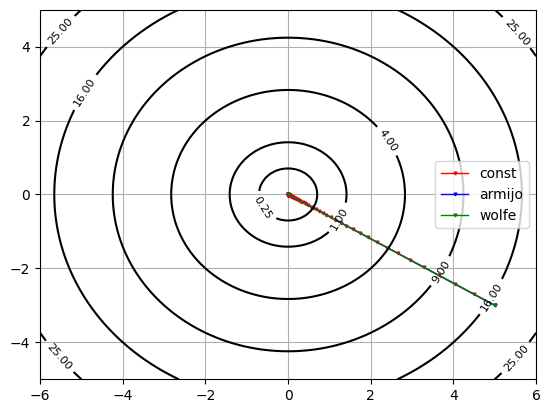

In [ ]:
plot_trajectory(func=oracle1.func, history=history1_const['x'], fit_axis=False, label="const", color='r')
plot_trajectory(func=oracle1.func, history=history1_armijo['x'], fit_axis=False, label="armijo", color='b')
plot_trajectory(func=oracle1.func, history=history1_wolfe['x'], fit_axis=False, label="wolfe", color='g')
plot_levels(oracle1.func)

У Армихо и Вульфа одинаковая траектория

/tmp/ipykernel_69992/2496985098.py:25: UserWarning: The following kwargs were not used by contour: 'linewidth'
  CS = plt.contour(X, Y, Z, levels=levels, colors='k', linewidth=4.0)


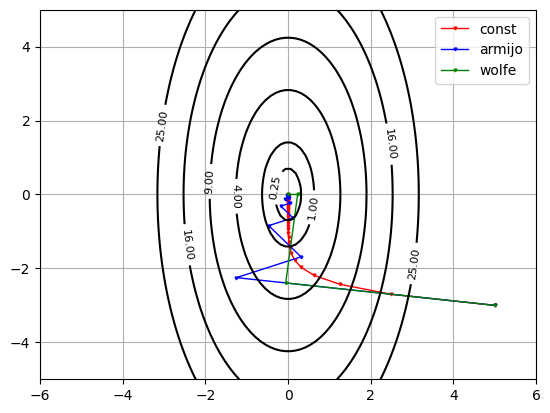

In [ ]:
plot_trajectory(func=oracle2.func, history=history2_const['x'], fit_axis=False, label="const", color='r')
plot_trajectory(func=oracle2.func, history=history2_armijo['x'], fit_axis=False, label="armijo", color='b')
plot_trajectory(func=oracle2.func, history=history2_wolfe['x'], fit_axis=False, label="wolfe", color='g')
plot_levels(oracle2.func)

/tmp/ipykernel_69992/2496985098.py:25: UserWarning: The following kwargs were not used by contour: 'linewidth'
  CS = plt.contour(X, Y, Z, levels=levels, colors='k', linewidth=4.0)


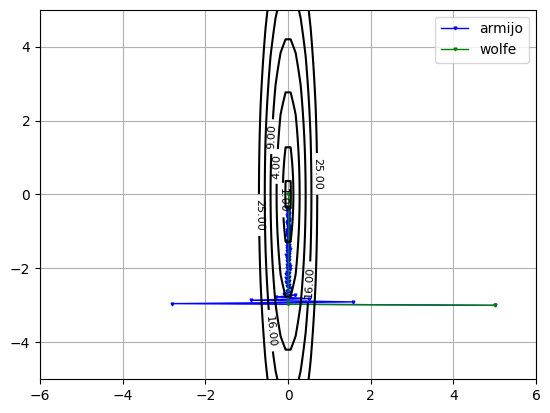

In [ ]:
# plot_trajectory(func=oracle3.func, history=history3_const['x'], fit_axis=False, label="const", color='r')  # не сошелся, не будем его рисовать
plot_trajectory(func=oracle3.func, history=history3_armijo['x'], fit_axis=False, label="armijo", color='b')
plot_trajectory(func=oracle3.func, history=history3_wolfe['x'], fit_axis=False, label="wolfe", color='g')
plot_levels(oracle3.func)

### Выводы

Как мы видим, все алгоритмы сходятся дольше при большем числе обусловленности матрицы.

Причем сходимость алгоритма констант очень сильно зависит от числа обусловленности. При очень большом числе обусловленности он перестает сходится.

Метод Армихо тоже сходится дольше при увеличении числа обусловленности, но куда быстрее метода констант.

А вот сходимость спуска с методом Вульфа куда меньше зависит от числа обусловленности, даже с большим числом обусловленности сходимость быстрая.

# Эксперимент 2: Зависимость числа итераций градиентного спуска от числа обусловленности и размерности пространства

Исследуйте, как зависит число итераций, необходимое градиентному спуску для сходимости, от следующих двух параметров:
1) числа обусловленности $k \geq 1$ оптимизируемой функции и
2) размерности пространства $n$ оптимизируемых переменных.

Для этого для заданных параметров $n$ и $k$ сгенерируйте случайным образом квадратичную задачу размера $n$ с числом обусловленности $k$ и запустите на ней градиентный спуск с некоторой фиксированной требуемой точностью. Замерьте число итераций $T(n,k)$, которое потребовалось сделать методу до сходимости (успешному выходу по критерию остановки).

**Рекомендация:** Проще всего сгенерировать случайную квадратичную задачу размера $n$ с заданным числом обусловленности $k$ следующим образом. В качестве матрицы $A \in S_{n}^{++}$ удобно взять просто диагональную матрицу $A = \text{Diag}(a)$, у которой диагональные элементы сгенерированы случайно в пределах $[1,k]$, причем $\min(a) = 1$, $\max(a) = k$. В качестве вектора $b \in \mathbb{R}^n$ можно взять вектор со случайными элементами. Диагональные матрицы удобно рассматривать, поскольку с ними можно эффективно работать даже при больших значениях $n$. Рекомендуется хранить матрицу $A$ в формате разреженной диагональной матрицы (см. $\texttt{scipy.sparse.diags}$).

Зафиксируйте некоторое значение размерности $n$. Переберите различные числа обусловленности $k$ по сетке и построите график зависимости $T(k,n)$ от $k$. Поскольку каждый раз квадратичная задача генерируется случайным образом, то повторите этот эксперимент несколько раз. В результате для фиксированного значения $n$ у Вас должно получиться целое семейство кривых зависимости $T(k,n)$ от $k$. Нарисуйте все эти кривые одним и тем же цветом для наглядности (например, красным).

Теперь увеличьте значение $n$ и повторите эксперимент снова. Вы должны получить новое семейство кривых $T(n',k)$ против $k$. Нарисуйте их все одним и тем же цветом, но отличным от предыдущего (например, синим).


Повторите эту процедуру несколько раз для других значений $n$. В итоге должно получиться несколько разных семейств кривых - часть красных (соответствующих одному значению $n$), часть синих (соответствующих другому значению $n$), часть зеленых и т. д.

Обратите внимание, что значения размерности $n$ имеет смысл перебирать по логарифмической сетке (например, $n = 10$, $n = 100$, $n = 1000$ и т. д.).

Какие выводы можно сделать из полученной картинки?



In [ ]:
np.random.seed(42)

In [ ]:
def gen_problem(n,k):
  diag = np.random.uniform(1, k, size=n)
  diag[0] = 1
  diag[1] = k
  A = diags(diag)
  b = np.random.randn(n)
  oracle = QuadraticOracle(A,b)
  return oracle

In [ ]:
N = [10, 100, 1000, 10000, 100000]
K = np.linspace(10, 1000, 10)
M = 5
tolerance = 1e-6


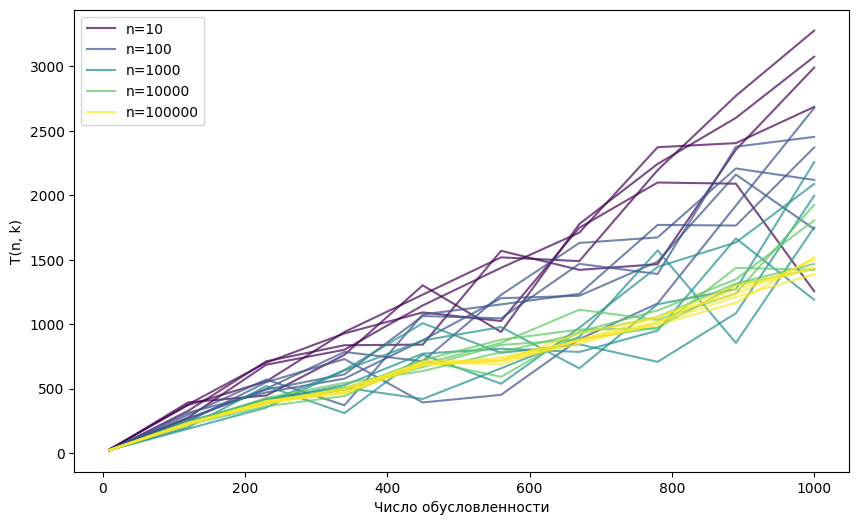

In [ ]:
plt.figure(figsize=(10,6))
colors = plt.cm.viridis(np.linspace(0, 1, len(N)))
c=0

seed = 1

for n in N:
    for m in range(M):
        np.random.seed(seed)
        result = []
        for k in K:
            oracle = gen_problem(n,k)

            x0 = np.zeros(n)
            x_star, message, history = gradient_descent(
                oracle,
                x0,
                tolerance=tolerance,
                max_iter=10000,
                line_search_options={'method': 'Armijo'},
                trace=True,
                display=False
            )

            result.append(len(history['func']))
        seed+=1

        plt.plot(K, result, color=colors[c], alpha=0.7, label=f'n={n}' if m == 0 else None)
    c+=1

plt.xlabel('Число обусловленности')
plt.ylabel('T(n, k)')
plt.legend()
plt.show()

Как мы видим, чем больше размерность пространства, тем меньше число итераций зависит от числа обусловленности.
При этом число итераций зависит от числа обусловленности примерно линейно.


# Задача 1: Обоснование константного шага для градиентного спуска

Рассмотрим квадратичную функцию $f(x) = \frac{1}{2}\langle Ax, x\rangle - \langle b, x\rangle$, где $A \in \mathbb{S}_{++}^n$,

Пусть
$
A = \begin{pmatrix}
5 & 1 \\
1 & 3
\end{pmatrix}, \quad
b = \begin{pmatrix}
1 \\ 2
\end{pmatrix}, \quad
x_0 = \begin{pmatrix}
0 \\ 0
\end{pmatrix}
$

Предъявите конкретное значение константного шага $\alpha$, гарантирующее сходимость градиентного спуска для данной функции, и строго обоснуйте свой выбор.


det(A - $\lambda$ I) = (5 - $\lambda$)(3 - $\lambda$) - 1 = $\lambda^2$ - 8 $\lambda$ + 14

Хотим

# Эксперимент 3: Стратегия выбора длины шага в градиентном спуске

Исследовать, как зависит поведение метода от стратегии подбора шага: константный шаг (попробовать различные значения), бэктрэкинг (попробовать различные константы $c$), условия Вульфа (попробовать различные параметры $c_2$), метод Брента и метод золотого сечения.

Рассмотрите квадратичную функцию и логистическую регрессию с модельными данными (сгенерированными случайно). (Следует рассматривать матрицы размерностью m, n = 10000, 8000, можно также рассмотреть и другие варианты)

Запустите для этих функций градиентный спуск с разными стратегиями выбора шага из одной и той же начальной точки.

Нарисуйте кривые сходимости (относительная невязка по функции в логарифмической шкале против числа итераций — для квадратичной функции, относительный квадрат нормы градиента в логарифмической шкале против числа итераций — для логистической регрессии) для разных стратегий на одном графике.

Попробуйте разные начальные точки. Ответьте на вопрос: Какая стратегия выбора шага является самой лучшей?



In [ ]:
def run_exp(oracle, x0, tools, max_iter, tolerance, trace):
    res = {}
    for i in range(len(tools)):
        print(tools[i][0])
        _, msg, history = gradient_descent(
            oracle,
            x0,
            max_iter=max_iter,
            tolerance=tolerance,
            line_search_options=tools[i][1],
            trace=trace,
            display=False
        )
        print(msg)
        res[tools[i][0]] = history
    return res

In [ ]:
def draw_plot(res, oracle_type):
    plt.figure(figsize=(10, 6))
    for name, history in res.items():
        if oracle_type == "quad":
            f_vals = np.array(history["func"])
            f_rel = np.abs(f_vals - f_vals[-1]) / (np.abs(f_vals[0] - f_vals[-1]) + 1e-16)
            plt.semilogy(f_rel, label=name)
        elif oracle_type == "logreg":
            grad_norm = np.array(history["grad_norm"])
            grad_rel = (grad_norm**2) / (grad_norm[0]**2 + 1e-16)
            plt.semilogy(grad_rel, label=name)
    plt.xlabel("Число итераций")
    plt.ylabel("Относительная ошибка")
    plt.legend()
    plt.show()

In [ ]:
tools = [
    ["Const 0.01", {"method": "Constant", "c": 0.01}],
    ["Const 0.001", {"method": "Constant", "c": 0.001}],
    ["Armijo 1e-4", {"method": "Armijo", "c1": 1e-4}],
    ["Armijo 1e-1", {"method": "Armijo", "c1": 1e-1}],
    ["Wolfe 1e-4 0.5", {"method": "Wolfe", "c1": 1e-4, "c2": 0.5}],
    ["Wolfe 1e-3 0.8", {"method": "Wolfe", "c1": 1e-3, "c2": 0.8}],
    ["Wolfe 1e-4 0.9", {"method": "Wolfe", "c1": 1e-4, "c2": 0.9}],
    ["Brent", {"method": "Brent"}],
    ["Golden", {"method": "Golden"}]
]

Эксперимент для квадратичной функции

Const 0.01
success
Const 0.001
iterations_exceeded
Armijo 1e-4
success
Armijo 1e-1
success
Wolfe 1e-4 0.5
success
Wolfe 1e-3 0.8
success
Wolfe 1e-4 0.9
success
Brent
success
Golden
success
Const 0.01
success
Const 0.001
iterations_exceeded
Armijo 1e-4
success
Armijo 1e-1
success
Wolfe 1e-4 0.5
success
Wolfe 1e-3 0.8
success
Wolfe 1e-4 0.9
success
Brent
success
Golden
success


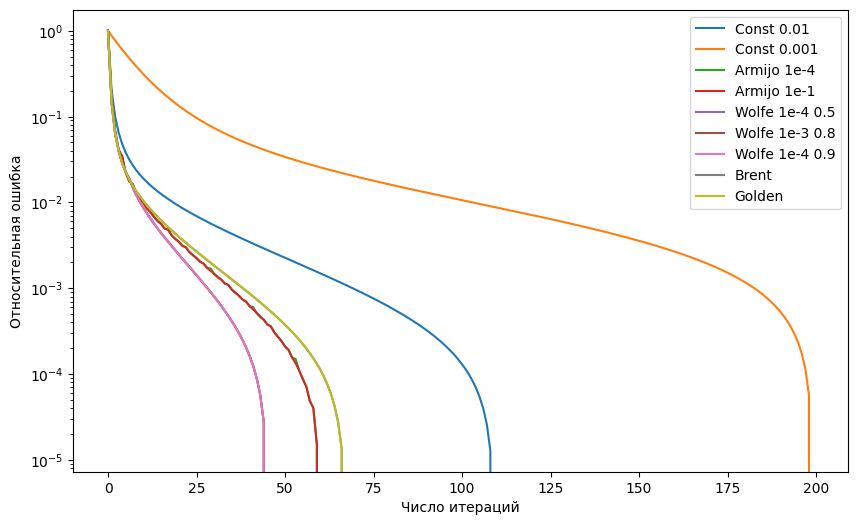

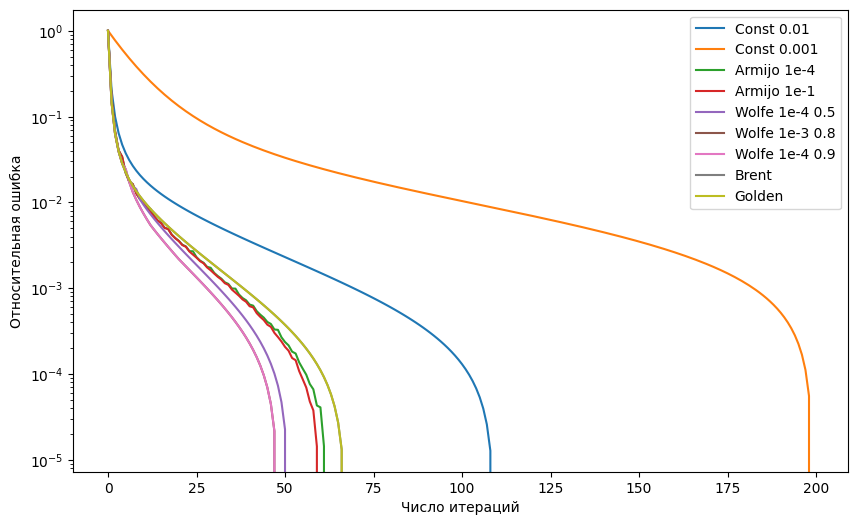

In [ ]:
m, n = 10000, 8000

np.random.seed(3)

A = diags(np.random.uniform(1, 100, size=n))
b = np.random.uniform(-15, 15, size=n)

quad_oracle = QuadraticOracle(A, b)

x0_1 = np.random.randn(n)
x0_2 = np.random.randn(n)


quad_results1 = run_exp(oracle=quad_oracle, x0=x0_1, tools=tools, max_iter=200, tolerance=1e-5, trace=True)
quad_results2 = run_exp(oracle=quad_oracle, x0=x0_2, tools=tools, max_iter=200, tolerance=1e-5, trace=True)
draw_plot(quad_results1, oracle_type="quad")
draw_plot(quad_results2, oracle_type="quad")

Метод констатнт с c=0.02 упорно не хочет сходится. При уменьшении c растет число итераций, при увеличении метод не сходится.

Как мы можем видеть по графикам, быстрее всего сходится метод Вульфа и метод Армихо

Эксперимент для ЛогРега

Const 0.01
iterations_exceeded
Const 0.001
iterations_exceeded
Armijo 1e-4
success
Armijo 1e-1
success
Wolfe 1e-4 0.5
success
Wolfe 1e-3 0.8
success
Wolfe 1e-4 0.9
success
Brent
success
Golden
success


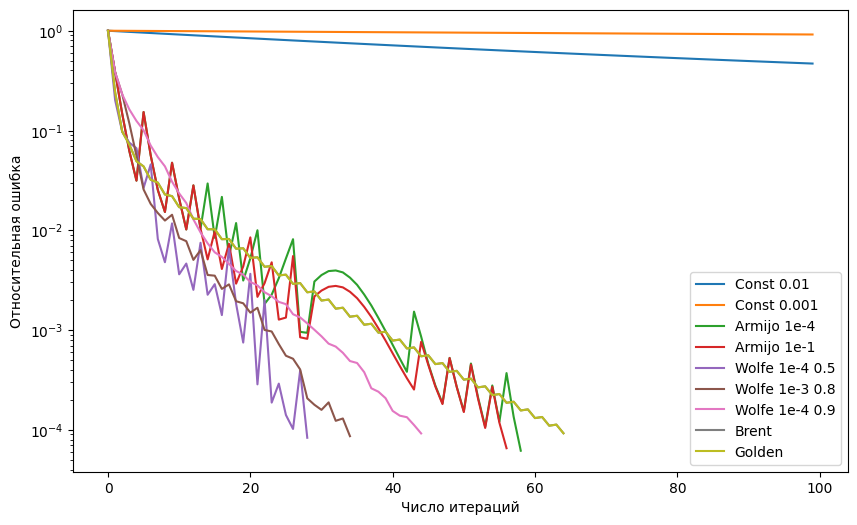

In [ ]:
tools = [
    ["Const 0.01", {"method": "Constant", "c": 0.01}],
    ["Const 0.001", {"method": "Constant", "c": 0.001}],
    ["Armijo 1e-4", {"method": "Armijo", "c1": 1e-4}],
    ["Armijo 1e-1", {"method": "Armijo", "c1": 1e-1}],
    ["Wolfe 1e-4 0.5", {"method": "Wolfe", "c1": 1e-4, "c2": 0.5}],
    ["Wolfe 1e-3 0.8", {"method": "Wolfe", "c1": 1e-3, "c2": 0.8}],
    ["Wolfe 1e-4 0.9", {"method": "Wolfe", "c1": 1e-4, "c2": 0.9}],
    ["Brent", {"method": "Brent"}],
    ["Golden", {"method": "Golden"}]
]


np.random.seed(3)

A_log = np.random.normal(0, 1, size=(m, n))
b_log = np.random.choice([-1, 1], size=m)
regcoef = 1e-3

logreg_oracle = create_log_reg_oracle(A_log, b_log, regcoef)
x0_1_logreg = np.zeros(n)

logreg_results = run_exp(oracle=logreg_oracle, x0=x0_1_logreg, tools=tools, max_iter=100, tolerance=1e-4, trace=True)
draw_plot(logreg_results, oracle_type="logreg")

Const 0.01
iterations_exceeded
Const 0.001
iterations_exceeded
Armijo 1e-4
success
Armijo 1e-1
success
Wolfe 1e-4 0.5
success
Wolfe 1e-3 0.8
success
Wolfe 1e-4 0.9
success
Brent
success
Golden
success


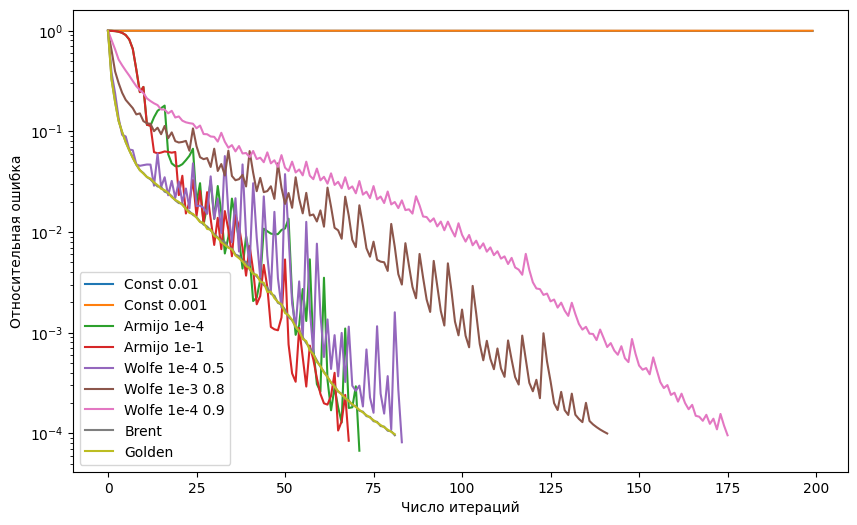

In [ ]:
np.random.seed(3)

x0_2_logreg = np.random.uniform(-10, 10, size=n)

logreg_results = run_exp(oracle=logreg_oracle, x0=x0_2_logreg, tools=tools, max_iter=200, tolerance=1e-4, trace=True)
draw_plot(logreg_results, oracle_type="logreg")

Для ЛогРега в для первой точки лучшим оказался метод Вульфа, для второй точки лучшими оказались методы Армихо и Brent/Golden.

В целом можно сказать, что методы Вульфа и Армихо при правильном выборе параметров являются лучшими

# Метод Нютона

Реализовать метод Ньютона (функция newton).

$$
x_{k+1} = x_k - \alpha_k \left[ \nabla^2 f(x_k) \right]^{-1} \nabla f(x_k)
$$

Для метода Ньютона очень важно использовать единичный шаг $\alpha_k = 1$, чтобы обеспечить локальную квадратичную сходимость. Поэтому в алгоритмах линейного поиска нужно всегда первым делом пробовать единичный шаг. Теория гарантирует, что в зоне квадратичной сходимости метода Ньютона единичный шаг будет удовлетворять условиям Армихо/Вульфа, и поэтому автоматически будет приниматься. Если единичный шаг не удовлетворяет условиям Армихо/Вульфа, то алгоритмы линейного поиска его уменьшат и, тем самым, обеспечат глобальную сходимость метода Ньютона.

Вычисление Ньютоновского направления $d_k = -\left[ \nabla^2 f(x_k) \right]^{-1} \nabla f(x_k)$ эквивалентно решению линейной системы уравнений:

$$\nabla^2 f(x_k) d_k = -\nabla f(x_k)$$

Если гессиан - положительно определённая матрица: $\nabla^2 f(x_k) \succ 0$, то предпочтительным методом решения такой системы является **разложение Холецкого**, которое также, как и метод Гаусса, работает за $O(n^3)$, но является вычислительно более эффективным. Если матрица системы не является положительно определённой, то метод Холецкого сможет обнаружить и сообщить об этом.

**Замечание:** Для поиска направления в методе Ньютона не нужно в явном виде обращать гессиан (с помощью функции np.linalg.inv) или использовать самый общий метод для решения системы линейных уравнений (numpy.linalg.solve). Вместо этого следует учесть тот факт, что в рассматриваемой задаче гессиан является симметричной положительно определенной матрицей и воспользоваться разложением Холецкого (функции scipy.linalg.cho_factor и scipy.linalg.cho_solve).

In [ ]:
from scipy.linalg import cho_factor, cho_solve
from scipy.sparse import issparse

def newton(oracle, x_0, tolerance=1e-5, max_iter=100,
           line_search_options=None, trace=False, display=False):
    """
    Newton's optimization method.

    Parameters
    ----------
    oracle : BaseSmoothOracle-descendant object
        Oracle with .func(), .grad() and .hess() methods implemented for computing
        function value, its gradient and Hessian respectively. If the Hessian
        returned by the oracle is not positive-definite method stops with message="newton_direction_error"
    x_0 : np.array
        Starting point for optimization algorithm
    tolerance : float
        Epsilon value for stopping criterion.
    max_iter : int
        Maximum number of iterations.
    line_search_options : dict, LineSearchTool or None
        Dictionary with line search options. See LineSearchTool class for details.
    trace : bool
        If True, the progress information is appended into history dictionary during training.
        Otherwise None is returned instead of history.
    display : bool
        If True, debug information is displayed during optimization.

    Returns
    -------
    x_star : np.array
        The point found by the optimization procedure
    message : string
        'success' or the description of error:
            - 'iterations_exceeded': if after max_iter iterations of the method x_k still doesn't satisfy
                the stopping criterion.
            - 'newton_direction_error': in case of failure of solving linear system with Hessian matrix (e.g. non-invertible matrix).
            - 'computational_error': in case of getting Infinity or None value during the computations.
    history : dictionary of lists or None
        Dictionary containing the progress information or None if trace=False.
        Dictionary has to be organized as follows:
            - history['time'] : list of floats, containing time passed from the start of the method
            - history['func'] : list of function values f(x_k) on every step of the algorithm
            - history['grad_norm'] : list of values Euclidian norms ||g(x_k)|| of the gradient on every step of the algorithm
            - history['x'] : list of np.arrays, containing the trajectory of the algorithm. ONLY STORE IF x.size <= 2

    Example:
    --------
    >> oracle = QuadraticOracle(np.eye(5), np.arange(5))
    >> x_opt, message, history = newton(oracle, np.zeros(5), line_search_options={'method': 'Constant', 'c': 1.0})
    >> print('Found optimal point: {}'.format(x_opt))
       Found optimal point: [ 0.  1.  2.  3.  4.]
    """
    history = None
    if trace:
        history = defaultdict(list)

    if line_search_options is None:
       line_search_options = dict()
    line_search_options['start_with_one'] = True

    line_search_tool = get_line_search_tool(line_search_options)

    x_k = np.copy(x_0)
    grad0 = oracle.grad(x_0)
    start_time = datetime.now()

    for k in range(max_iter):
        try:
          f_k = oracle.func(x_k)
          g_k = oracle.grad(x_k)
          grad_norm = np.linalg.norm(g_k)
        except Exception as e:
          print("Ошибка в вычислении f_k, g_k, grad_norm:", e)
        try:
          if trace:
              history['func'].append(f_k)
              history['grad_norm'].append(grad_norm)
              history['time'].append((datetime.now() - start_time).total_seconds())
              if x_k.size <= 2:
                  history['x'].append(np.copy(x_k))
        except Exception as e:
          print("Ошибка в записи в историю:", e)

        try:
          if grad_norm**2 <= tolerance * np.linalg.norm(grad0)**2:
              print("success")
              return x_k, "success", history
        except:
          print("Ошибка в проверке критерия остановки")
        try:
          H_k = oracle.hess(x_k)
        except Exception as e:
          print("Ошибка в вычислении гессиана:", e)
        try:
            if issparse(H_k):
              H_k = H_k.toarray()
            c, low = cho_factor(H_k)
            d_k = cho_solve((c, low), -g_k)
        except Exception:
            return x_k, 'newton_direction_error', history

        try:
          alpha_k = line_search_tool.line_search(oracle, x_k, d_k)
        except:
          print("Ошибка в вычислении alpha_k")

        if alpha_k is None or alpha_k <= 0:
            alpha_k = 1.0

        x_k = x_k + alpha_k * d_k

        if display:
            print(f"Iter {k}: f={f_k:.6e}, ||grad||={grad_norm:.6e}, alpha={alpha_k:.3e}")

    return x_k, "iterations_exceeded", history

# Эксперимент 4: Сравнение методов градиентного спуска и Ньютона на реальной задаче логистической регрессии

Сравнить методы градиентного спуска и Ньютона на задаче обучения логистической регрессии на реальных данных. В качестве реальных данных используйте следующие три набора с сайта LIBSVM [3]: $\texttt{w8a}$, $\texttt{gisette}$ и $\texttt{real-sim}$. https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/

Коэффициент регуляризации взять стандартным образом: $\lambda = \frac{1}{m}$.

Параметры обоих методов взять равными параметрам по умолчанию.

Начальную точку выбрать $x_0 = 0$.

Построить графики сходимости следующих двух видов:

(a) Зависимость значения функции от реального времени работы метода.

(b) Зависимость относительного квадрата нормы градиента $\frac{\|\nabla f(x_k)\|^2}{\|\nabla f(x_0)\|^2}$ (в логарифмической шкале) против реального времени работы.

При этом оба метода (градиентный спуск и Ньютон) нужно рисовать на одном и том же графике.

Укажите в отчете, какова стоимость итерации и сколько памяти требуется каждому из методов в зависимости от параметров $m$ (размер выборки) и $n$ (размерность пространства). При оценке используйте нотацию $O(\cdot)$, скрывающую внутри себя абсолютные константы.

Какие выводы можно сделать по результатам этого эксперимента? Какой из методов лучше и в каких ситуациях?

*Рекомендация:* Любой набор данных с сайта LIBSVM представляет из себя текстовый файл в формате svmlight. Чтобы считать такой текстовый файл, можно использовать функцию $\texttt{load_svmlight_file}$ из модуля $\texttt{sklearn.datasets}$. Обратите внимание, что эта функция возвращает матрицу в формате $\texttt{scipy.sparse.csr_matrix}$, поэтому Ваша реализация логистического оракула должна поддерживать такие матрицы.

In [ ]:
from sklearn.datasets import load_svmlight_file

In [ ]:
!wget https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/w8a
!wget https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/gisette_scale.bz2
!bunzip2 gisette_scale.bz2
!wget https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/real-sim.bz2


In [ ]:
!bunzip2 real-sim.bz2


In [ ]:
data_w8a = load_svmlight_file("w8a")
data_gisette = load_svmlight_file("gisette_scale")
data_real_sim = load_svmlight_file("real-sim")

In [ ]:
data_w8a_X = data_w8a[0]
data_w8a_y = data_w8a[1]

In [ ]:
data_gisette_X = data_gisette[0]
data_gisette_y = data_gisette[1]

In [ ]:
data_real_sim_X = data_real_sim[0]
data_real_sim_y = data_real_sim[1]

In [ ]:
oracle = create_log_reg_oracle(data_w8a_X, data_w8a_y, regcoef=1e-4)
x0 = np.zeros(data_w8a_X.shape[1])
max_iter=200
tolerance=1e-8

In [ ]:
x_gd, msg_gd, history_gd = gradient_descent(
    oracle=oracle,
    x_0=x0,
    trace=True,
    display=True,
    tolerance=tolerance,
    max_iter=max_iter
    )

print(msg_gd)

Iter 0: f=6.931472e-01, ||grad||=5.625363e-01, alpha=1.000e+00
Iter 1: f=4.666644e-01, ||grad||=2.756966e-01, alpha=1.000e+00
Iter 2: f=4.019013e-01, ||grad||=1.995880e-01, alpha=1.000e+00
Iter 3: f=3.661264e-01, ||grad||=1.607620e-01, alpha=1.000e+00
Iter 4: f=3.423239e-01, ||grad||=1.362378e-01, alpha=1.000e+00
Iter 5: f=3.249709e-01, ||grad||=1.190006e-01, alpha=1.000e+00
Iter 6: f=3.115971e-01, ||grad||=1.060791e-01, alpha=2.000e+00
Iter 7: f=2.912039e-01, ||grad||=8.695510e-02, alpha=2.000e+00
Iter 8: f=2.772172e-01, ||grad||=7.430739e-02, alpha=2.000e+00
Iter 9: f=2.668677e-01, ||grad||=6.522102e-02, alpha=2.000e+00
Iter 10: f=2.588198e-01, ||grad||=5.833740e-02, alpha=4.000e+00
Iter 11: f=2.464535e-01, ||grad||=4.809040e-02, alpha=4.000e+00
Iter 12: f=2.378776e-01, ||grad||=4.131509e-02, alpha=4.000e+00
Iter 13: f=2.314624e-01, ||grad||=3.647272e-02, alpha=4.000e+00
Iter 14: f=2.264145e-01, ||grad||=3.282964e-02, alpha=8.000e+00
Iter 15: f=2.185340e-01, ||grad||=2.745911e-02, al

In [ ]:
x_newton, msg_newton, history_newton = newton(
    oracle=oracle,
    x_0=x0,
    trace=True,
    display=True,
    tolerance=tolerance,
    max_iter=max_iter
    )

Iter 0: f=6.931472e-01, ||grad||=5.625363e-01, alpha=1.000e+00
Iter 1: f=3.199079e-01, ||grad||=1.657423e-01, alpha=1.000e+00
Iter 2: f=2.244186e-01, ||grad||=6.758594e-02, alpha=1.000e+00
Iter 3: f=1.770801e-01, ||grad||=2.760034e-02, alpha=1.000e+00
Iter 4: f=1.538321e-01, ||grad||=1.060103e-02, alpha=1.000e+00
Iter 5: f=1.446678e-01, ||grad||=3.419273e-03, alpha=1.000e+00
Iter 6: f=1.425618e-01, ||grad||=7.273662e-04, alpha=1.000e+00
Iter 7: f=1.423999e-01, ||grad||=5.763615e-05, alpha=1.000e+00
success


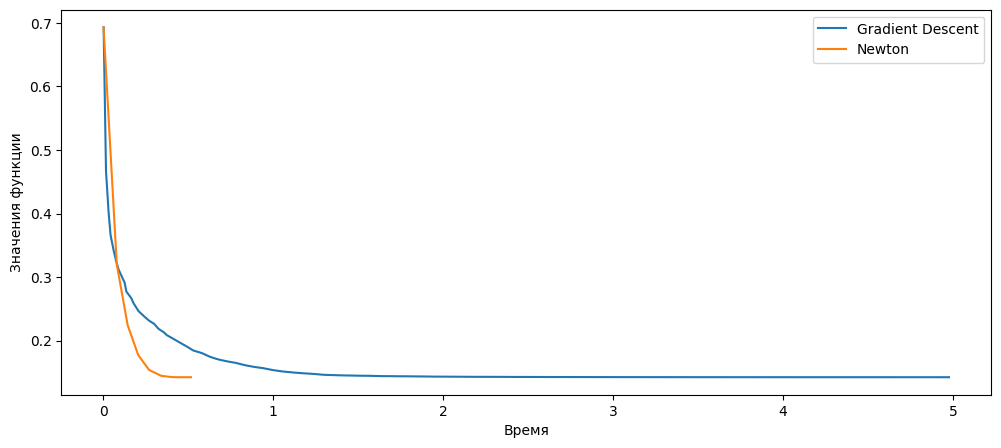

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(history_gd['time'], history_gd['func'], label='Gradient Descent')
plt.plot(history_newton['time'], history_newton['func'], label='Newton')
plt.xlabel('Время')
plt.ylabel('Значения функции')
plt.legend()
plt.show()

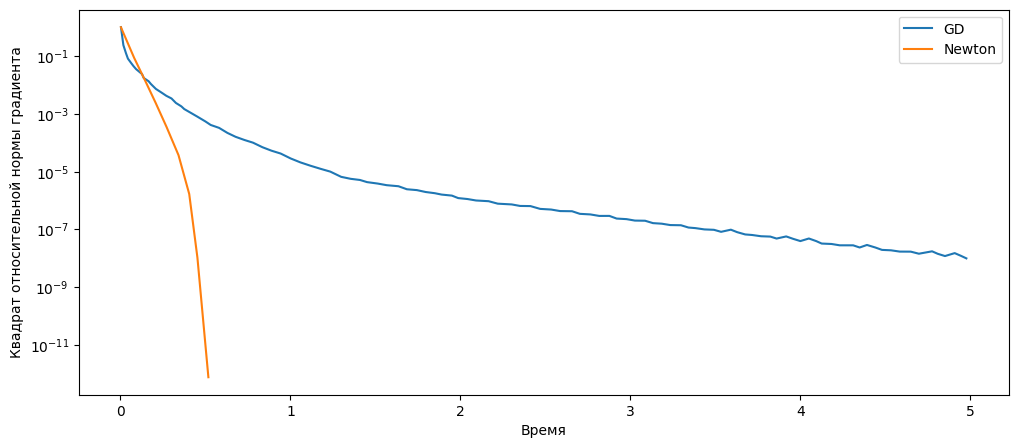

In [ ]:
grad0_gd = history_gd['grad_norm'][0]
grad0_newton = history_newton['grad_norm'][0]

plt.figure(figsize=(12,5))
plt.semilogy(history_gd['time'], np.array(history_gd['grad_norm'])**2 / grad0_gd**2, label='GD')
plt.semilogy(history_newton['time'], np.array(history_newton['grad_norm'])**2 / grad0_newton**2, label='Newton')
plt.xlabel('Время')
plt.ylabel('Квадрат относительной нормы градиента')
plt.legend()
plt.show()

### Real Slim

In [ ]:
oracle = create_log_reg_oracle(data_real_sim_X, data_real_sim_y, regcoef=1e-4)
x0 = np.zeros(data_real_sim_X.shape[1])
max_iter=100
tolerance=1e-6

In [ ]:
x_gd, msg_gd, history_gd = gradient_descent(
    oracle=oracle,
    x_0=x0,
    trace=True,
    display=False,
    tolerance=tolerance,
    max_iter=max_iter
    )

print(msg_gd)

c:\Users\sasha\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\optimize\_linesearch.py:466: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)


success


In [ ]:
x_newton, msg_newton, history_newton = newton(
    oracle=oracle,
    x_0=x0,
    trace=True,
    display=True,
    tolerance=tolerance,
    max_iter=max_iter
    )

Iter 0: f=6.931472e-01, ||grad||=3.320754e-02, alpha=1.000e+00
Iter 1: f=3.178912e-01, ||grad||=7.632913e-03, alpha=1.000e+00
Iter 2: f=2.801883e-01, ||grad||=2.032627e-03, alpha=1.000e+00
Iter 3: f=2.759520e-01, ||grad||=2.865325e-04, alpha=1.000e+00
success


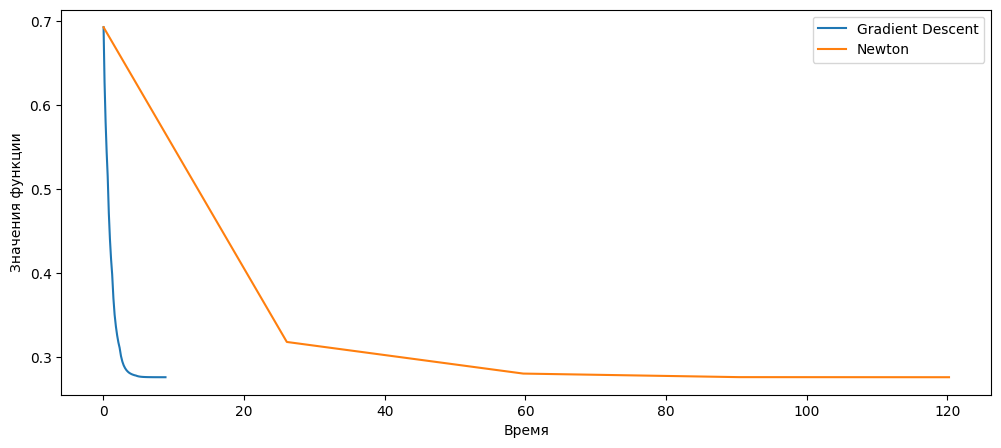

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(history_gd['time'], history_gd['func'], label='Gradient Descent')
plt.plot(history_newton['time'], history_newton['func'], label='Newton')
plt.xlabel('Время')
plt.ylabel('Значения функции')
plt.legend()
plt.show()

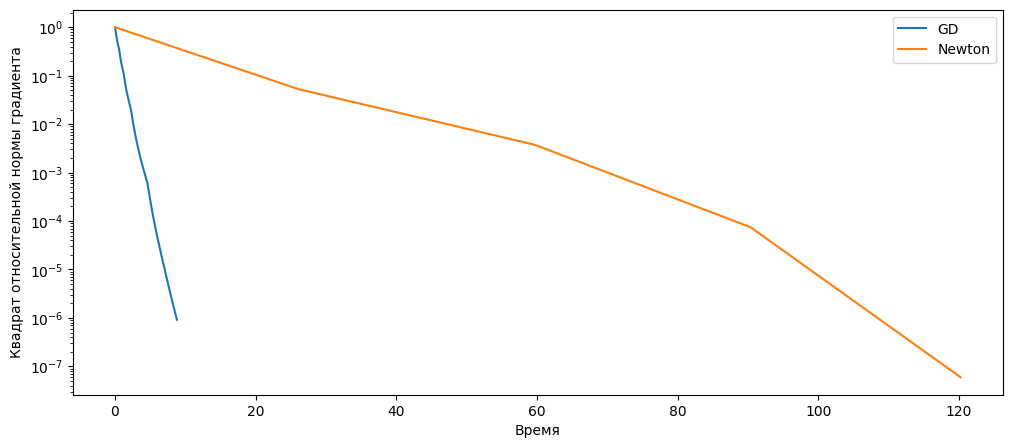

In [ ]:
grad0_gd = history_gd['grad_norm'][0]
grad0_newton = history_newton['grad_norm'][0]

plt.figure(figsize=(12,5))
plt.semilogy(history_gd['time'], np.array(history_gd['grad_norm'])**2 / grad0_gd**2, label='GD')
plt.semilogy(history_newton['time'], np.array(history_newton['grad_norm'])**2 / grad0_newton**2, label='Newton')
plt.xlabel('Время')
plt.ylabel('Квадрат относительной нормы градиента')
plt.legend()
plt.show()

Система падает при вычислении гессиана на gissete. Colab со своими процессорами такое не тянет, а пытать свой cpu я не хочу, поэтому ограничимся экспериментами с двумя датасетами.



Можно сказать, что на маленьком наборе данных Ньютон работает быстрее обычного GD, однако на больших наборах использование Ньютона не целесообразно, так как потребление памяти очень большое. Мб если вычислять гессиан так же в sparse-матрицах, проблему можно решить. Так же неплохо было бы делать все матричные операции на gpu.


GD:
Стоимость операции: O(mn) (с плотными матрицами)
Память: O(mn) (хранить плотную матрицу -- O(mn), остальное очев меньше)

Newton:
Стоимость операции: посчитать гессиан -- O(mn^2), решить систему -- O(n^3), итого O(mn^2 + n^3)
Память: хранить гессиан -- O(n^2), хранить A -- O(mn), итого O(mn + n^2)


Итого: Ньютона можно использовать на небольших наборах данных, там он будет эффективнее GD, так как сходится быстрее (судя по графикам). При большом размере данных Ньютона использовать не получится

# Эксперимент 5: Стратегия выбора длины шага в методе Ньютона



Повторите эксперимент 3 со сравнением стратегий выбора шага на логистической регрессии с модельной выборкой, но для метода Ньютона. Какая стратегия работает лучше всего?



In [ ]:
def run_exp(oracle, x0, tools, max_iter, tolerance, trace):
    res = {}
    for i in range(len(tools)):
        print(tools[i][0])
        _, msg, history = newton(
            oracle,
            x0,
            max_iter=max_iter,
            tolerance=tolerance,
            line_search_options=tools[i][1],
            trace=trace,
            display=False
        )
        res[tools[i][0]] = history
    return res


def draw_plot(res):
    plt.figure(figsize=(10, 6))
    for name, history in res.items():
      grad_norm = np.array(history["grad_norm"])
      grad_rel = (grad_norm**2) / (grad_norm[0]**2 + 1e-16)
      plt.semilogy(grad_rel, label=name)
    plt.xlabel("Число итераций")
    plt.ylabel("Относительная ошибка")
    plt.legend()
    plt.show()

In [ ]:
tools = [
    ["Const 0.1", {"method": "Constant", "c": 0.1}],
    ["Const 0.01", {"method": "Constant", "c": 0.01}],
    ["Const 0.001", {"method": "Constant", "c": 0.001}],
    ["Armijo 1e-4", {"method": "Armijo", "c1": 1e-4}],
    ["Armijo 1e-1", {"method": "Armijo", "c1": 1e-1}],
    ["Wolfe 1e-4 0.5", {"method": "Wolfe", "c1": 1e-4, "c2": 0.5}],
    ["Wolfe 1e-3 0.8", {"method": "Wolfe", "c1": 1e-3, "c2": 0.8}],
    ["Wolfe 1e-4 0.9", {"method": "Wolfe", "c1": 1e-4, "c2": 0.9}],
    ["Brent", {"method": "Brent"}],
    ["Golden", {"method": "Golden"}]
]

Const 0.1
Const 0.01
Const 0.001
Armijo 1e-4
success
Armijo 1e-1
success
Wolfe 1e-4 0.5
success
Wolfe 1e-3 0.8
success
Wolfe 1e-4 0.9
success
Brent
success
Golden
success


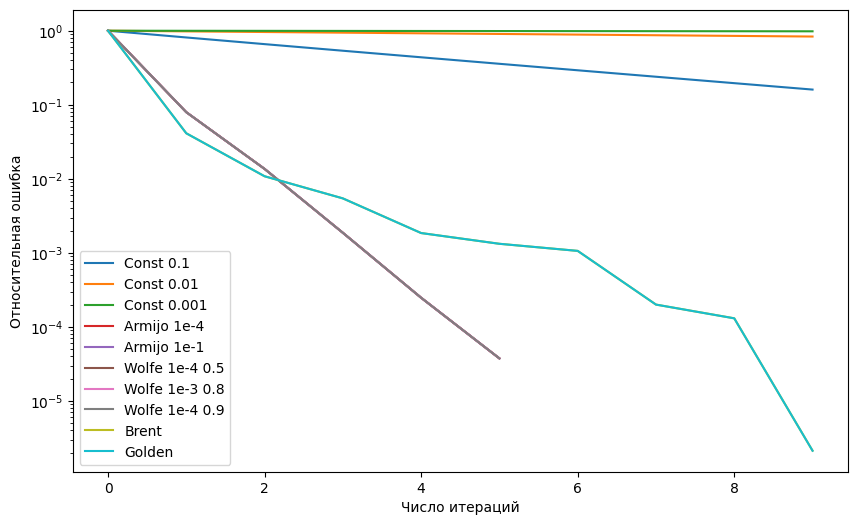

In [ ]:
np.random.seed(3)

m, n = 10000, 8000

A_log = np.random.normal(0, 1, size=(m, n))
b_log = np.random.choice([-1, 1], size=m)
regcoef = 1e-4

logreg_oracle = create_log_reg_oracle(A_log, b_log, regcoef)
x0_1_logreg = np.zeros(n)

logreg_results = run_exp(oracle=logreg_oracle, x0=x0_1_logreg, tools=tools, max_iter=10, tolerance=1e-4, trace=True)
draw_plot(logreg_results)

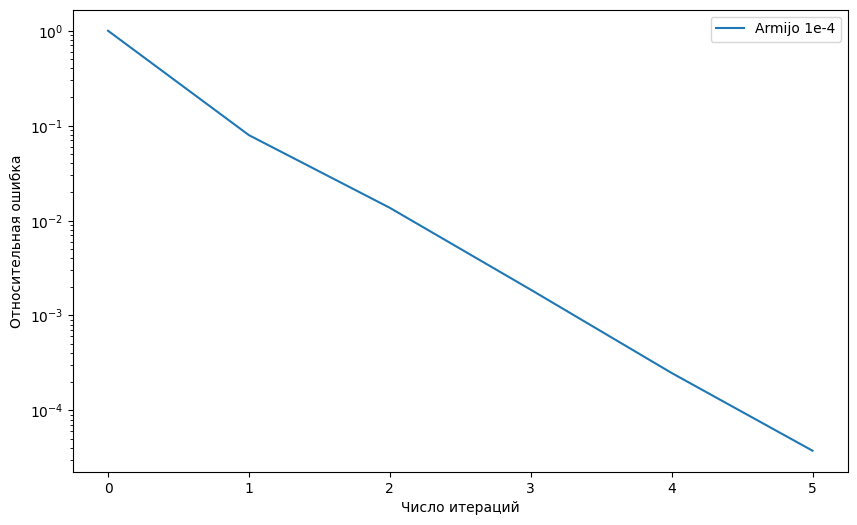

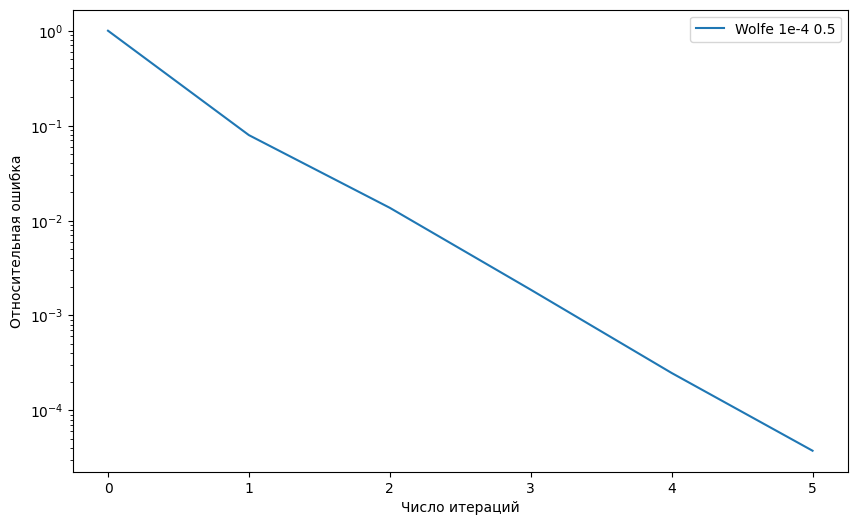

In [ ]:
draw_plot({'Armijo 1e-4': logreg_results['Armijo 1e-4']})
draw_plot({'Wolfe 1e-4 0.5': logreg_results['Wolfe 1e-4 0.5']})

Как мы видим, быстрее всего отработали все методы Армихо и Вульфа (да, они идеально совпали). Методы Golden/Brent тоже сошлись, но через большее число эпох. А константные методы не сошлись, наверное такие константы не подходят